## Datos de Apophis

Unidades canonicas:
  UL = 1.495979e+11 m
  UM = 1.988470e+30 kg
  UT = 5.022567e+06 s
  Gc = 1


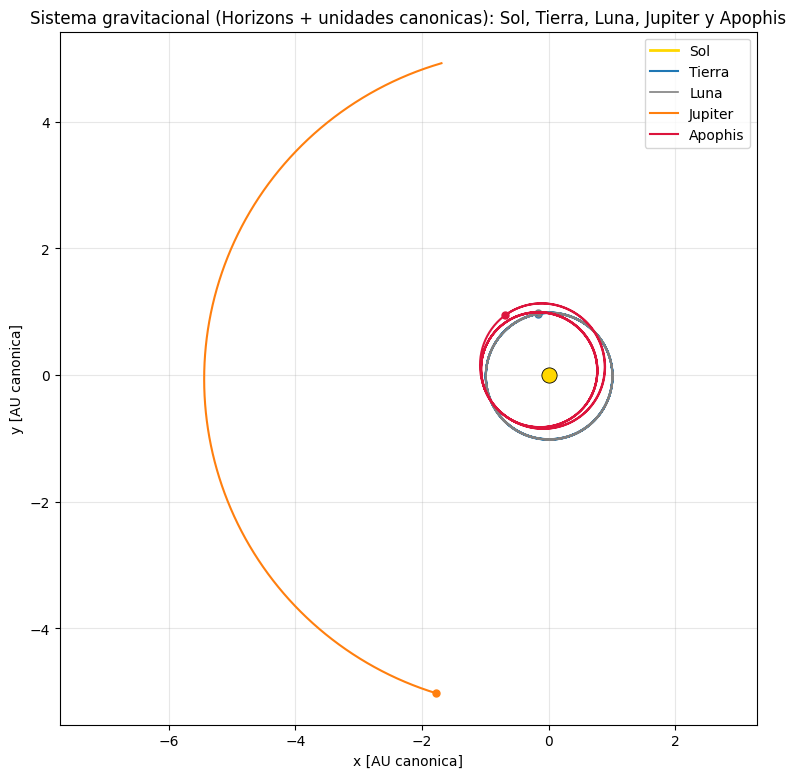

Energia total del sistema (canonicas): -9.325378e-05


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
import pymcel as pc

# =========================
# 1) Datos desde Horizons
# =========================
epochs = '2026-01-01 00:00:00'
propiedades = [('x', 'm'), ('y', 'm'), ('z', 'm'), ('vx', 'm/s'), ('vy', 'm/s'), ('vz', 'm/s')]

# IDs de Horizons y nombres en la simulacion
cuerpos = [
    ('Sol', '10'),
    ('Tierra', '399'),
    ('Luna', '301'),
    ('Jupiter', '599'),
    ('Apophis', '99942'),
]

# Masas en SI [kg]
masas_si = {
    'Sol': 1.98847e30,
    'Tierra': 5.9722e24,
    'Luna': 7.34767309e22,
    'Jupiter': 1.89813e27,
    'Apophis': 3.4e10,
}

estados_si = {}
for nombre, obj_id in cuerpos:
    tabla, ts, salida = pc.consulta_horizons(
        id=obj_id,
        location='@0',
        datos='vectors',
        propiedades=propiedades,
        epochs=epochs,
    )
    estados_si[nombre] = np.array(salida, dtype=float).reshape(-1)

# ==================================
# 2) Unidades canonicas (AU, Msun)
# ==================================
UL = 1.495978707e11   # 1 AU en metros
UM = 1.98847e30       # 1 Msun en kg
UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)  # Gc = 1

vel_unit = UL / UT

# Conversion SI -> canonico
estados_can = {}
for nombre, vec in estados_si.items():
    x, y, z, vx, vy, vz = vec
    estados_can[nombre] = np.array([
        x / UL,
        y / UL,
        z / UL,
        vx / vel_unit,
        vy / vel_unit,
        vz / vel_unit,
    ])

masas_can = {nombre: masas_si[nombre] / UM for nombre, _ in cuerpos}

print('Unidades canonicas:')
print(f'  UL = {UL:.6e} m')
print(f'  UM = {UM:.6e} kg')
print(f'  UT = {UT:.6e} s')
print(f'  Gc = {Gc}')

# =============================
# 3) Simulacion con REBOUND
# =============================
sim = rebound.Simulation()
sim.integrator = 'ias15'
sim.G = Gc

for nombre, _ in cuerpos:
    x, y, z, vx, vy, vz = estados_can[nombre]
    sim.add(
        m=masas_can[nombre],
        x=x,
        y=y,
        z=z,
        vx=vx,
        vy=vy,
        vz=vz,
        hash=nombre,
    )

sim.move_to_com()

# Tiempo de integracion: 5 anos SI -> canonico
tmax_years = 5.0
tmax_si = tmax_years * 365.25 * 24 * 3600.0
tmax_can = tmax_si / UT

N = 1200
times = np.linspace(0.0, tmax_can, N)

names = [nombre for nombre, _ in cuerpos]
coords = {name: np.zeros((N, 2)) for name in names}

for i, t in enumerate(times):
    sim.integrate(t)
    for name in names:
        p = sim.particles[name]
        coords[name][i, 0] = p.x
        coords[name][i, 1] = p.y

# =============================
# 4) Grafica de trayectorias
# =============================
plt.figure(figsize=(9, 9))
styles = {
    'Sol': dict(color='gold', lw=2.0),
    'Tierra': dict(color='tab:blue', lw=1.5),
    'Luna': dict(color='gray', lw=1.2),
    'Jupiter': dict(color='tab:orange', lw=1.5),
    'Apophis': dict(color='crimson', lw=1.5),
}

for name in names:
    plt.plot(coords[name][:, 0], coords[name][:, 1], label=name, **styles[name])
    plt.scatter(coords[name][-1, 0], coords[name][-1, 1], s=25, color=styles[name]['color'])

plt.scatter(0, 0, color='gold', s=120, edgecolor='black', linewidth=0.6, zorder=5)
plt.title('Sistema gravitacional (Horizons + unidades canonicas): Sol, Tierra, Luna, Jupiter y Apophis')
plt.xlabel('x [AU canonica]')
plt.ylabel('y [AU canonica]')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Energia total en unidades canonicas
E = sim.energy()
print(f'Energia total del sistema (canonicas): {E:.6e}')

In [5]:
import pymcel as pc
import numpy as np

epochs = '2026-01-01 00:00:00'
propiedades = [('x','m'), ('y','m'), ('z','m'), ('vx','m/s'), ('vy','m/s'), ('vz','m/s')]

for obj_id in ['10', '399', '301', '599', '99942']:
    tabla, ts, salida = pc.consulta_horizons(
        id=obj_id,
        location='@0',
        datos='vectors',
        propiedades=propiedades,
        epochs=epochs,
    )
    arr = np.array(salida, dtype=float).reshape(-1)
    print(f"ID {obj_id}: target={tabla['targetname'][0]}")
    print('  estado [x,y,z,vx,vy,vz] SI =', arr)

UL, UM, UT, Gc = pc.unidades_canonicas(UL=1.495978707e11, UM=1.98847e30)
print('\nCanonicas (AU, Msun):')
print('UL [m]=', UL)
print('UM [kg]=', UM)
print('UT [s]=', UT)
print('Gc=', Gc)
print('vel unit [m/s]=', UL/UT)

ID 10: target=Sun (10)
  estado [x,y,z,vx,vy,vz] SI = [-4.58863967e+08 -8.27774247e+08  1.96996750e+07  1.24250579e+01
  3.07876248e-01 -2.35280331e-01]
ID 399: target=Earth (399)
  estado [x,y,z,vx,vy,vz] SI = [-2.65310024e+10  1.43946900e+11  1.08068131e+07 -2.97765061e+04
 -5.39596266e+03  1.75383620e-01]
ID 301: target=Moon (301)
  estado [x,y,z,vx,vy,vz] SI = [-2.63866767e+10  1.44276295e+11  4.25597895e+07 -3.07808202e+04
 -4.97509745e+03  5.76059492e+00]
ID 599: target=Jupiter (599)
  estado [x,y,z,vx,vy,vz] SI = [-2.53878209e+11  7.36522532e+11  2.62662518e+09 -1.25076163e+04
 -3.63998664e+03  2.94911402e+02]
ID 99942: target=99942 Apophis (2004 MN4)
  estado [x,y,z,vx,vy,vz] SI = [ 9.43506820e+10 -5.94965529e+10  5.39320176e+09  1.96416067e+04
  3.20816729e+04 -1.24824123e+03]

Canonicas (AU, Msun):
UL [m]= 149597870700.0
UM [kg]= 1.98847e+30
UT [s]= 5022566.95133688
Gc= 1
vel unit [m/s]= 29785.142169221028
